<a href="https://colab.research.google.com/github/lollopelle01/IPCV_assignments/blob/main/Assignment_2/assignment_module_two_BRUTTA_COPIA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

STUDENTS:

- 0001189550, Lorenzo Pellegrino, lorenzo.pellegrino2@studio.unibo.it
- 0001169261, Giorgio Scavello, giorgio.scavello@studio.unibo.it
- 0001189587, Leonardo Billi, leonardo.billi@studio.unibo.it

# Assignment Module 2: Pet Classification

The goal of this assignment is to implement a neural network that classifies images of 37 breeds of cats and dogs from the [Oxford-IIIT-Pet dataset](https://www.robots.ox.ac.uk/~vgg/data/pets/). The assignment is divided into two parts: first, you will be asked to implement from scratch your own neural network for image classification; then, you will fine-tune a pretrained network provided by PyTorch.

## Dataset

The following cells contain the code to download and access the dataset you will be using in this assignment. Note that, although this dataset features each and every image from [Oxford-IIIT-Pet](https://www.robots.ox.ac.uk/~vgg/data/pets/), it uses a different train-val-test split than the original authors.

In [1]:
! git clone https://github.com/CVLAB-Unibo/ipcv-assignment-2.git
! pip install --upgrade torchmetrics torchinfo gdown

Cloning into 'ipcv-assignment-2'...
remote: Enumerating objects: 7371, done.
remote: Total 7371 (delta 0), reused 0 (delta 0), pack-reused 7371 (from 1)
Receiving objects: 100% (7371/7371), 753.77 MiB | 26.11 MiB/s, done.
Updating files: 100% (7396/7396), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 19.9 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Dataset
from torchvision import transforms, models
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from torchmetrics import Accuracy, ConfusionMatrix
from torchinfo import summary
import wandb
from tqdm import tqdm
from pathlib import Path
from typing import Dict, Any, Tuple, List
import copy
from PIL import Image
import matplotlib.pyplot as plt
from torch import Tensor
import numpy as np
import random
from collections import defaultdict
import pickle
import os
import gdown
from copy import deepcopy
import seaborn as sns

#from google.colab import drive
#drive.mount('/content/drive')

CACHE_DIR = "weights"
WANDB_KEY = "..."       # Change this
WANDB_USER = "..."      # Change this
WANDB_PROJECT = "..."   # Change this
PATH_LOCAL = "ipcv-assignment-2"

# Reproducibility
def fix_random(seed: int) -> None:
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
fix_random(42)



# NOTE1: this is done always, to run the models uncomment this section or change the CACHE_DIR
# NOTE2: sometimes this fails, disconnect the runtime and run again to solve it
folder_link = "https://drive.google.com/drive/folders/12QL1ESwCwwna-Q23ojoj5rdDi20wJPwK"
os.makedirs(CACHE_DIR, exist_ok=True)
gdown.download_folder(
    url=folder_link,
    output=CACHE_DIR,
    quiet=False,
    use_cookies=False
)



DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

Retrieving folder contents


Processing file 1WWrBe3uJkZv2Q7nsQqzGbmVBCeCxpz5K 1-block.pkl
Processing file 1UNF8ieX57FPuAac6mnSdvBrrX2ysoL1Z 1-block.pt
Processing file 1z-8gbvMxpgwEZML_dnb4yeq60wLE4G55 1-conv.pkl
Processing file 1IRakgGw_XjWm32ap7FB4EdH2ySbuJbju 1-conv.pt
Processing file 1Ozh7fm8cAdnvhkLCvQVf2L3Q_1SqQjMy 1+block.pkl
Processing file 1LITlFaS9kfnICiDfIFDiXWFmjbAoJtNQ 1+block.pt
Processing file 10GqGRNe-0PBB7NWXtWxwmJff6jcpO0vS 1+conv.pkl
Processing file 1nS58MEwWw0ePCLCDxrgnRDGEx1MLRpZA 1+conv.pt
Processing file 1ROk3Sx_oOsoMGqQiPDTjUarwCH-BhrcU best_model.pkl
Processing file 1qbkHGMBYtjthPch4dkPJzB0W8NwlwU3u best_model.pt
Processing file 1tzt3lnItWQ5NVZPqFSiDOiTnod4l34Tt lr-.pkl
Processing file 1M5pJATX0yPXAK6R8T5mQ72eBLBg_6ucZ lr-.pt
Processing file 1UzrfEsqZzxI70JIU4MMm8pzZSFl2FGnt lr+.pkl
Processing file 1ArFVwAD2rEli2GOlWChISBPNDGRBmrY1 lr+.pt
Processing file 1K31ixA37ILaKu2415st9vq3C55k_H-3m no_batchnorm_adapt_lr.pkl
Processing file 1l70eYlsw23pLIp4IM7Ay1QpsDNTNZfhZ no_batchnorm_adapt_lr.pt
Pr

Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1WWrBe3uJkZv2Q7nsQqzGbmVBCeCxpz5K
To: /content/weights/1-block.pkl
100%|██████████| 9.84k/9.84k [00:00<00:00, 15.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1UNF8ieX57FPuAac6mnSdvBrrX2ysoL1Z
To: /content/weights/1-block.pt
100%|██████████| 18.7M/18.7M [00:00<00:00, 62.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1z-8gbvMxpgwEZML_dnb4yeq60wLE4G55
To: /content/weights/1-conv.pkl
100%|██████████| 9.84k/9.84k [00:00<00:00, 15.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=1IRakgGw_XjWm32ap7FB4EdH2ySbuJbju
To: /content/weights/1-conv.pt
100%|██████████| 25.3M/25.3M [00:00<00:00, 124MB/s] 
Downloading...
From: https://drive.google.com/uc?id=1Ozh7fm8cAdnvhkLCvQVf2L3Q_1SqQjMy
To: /content/weights/1+block.pkl
100%|██████████| 9.84k/9.84k [00:00<00:00, 23.1MB/s]
Downloading...
From (original): https:/

Using device: cpu



Download completed


In [3]:
class OxfordPetDataset(Dataset):
    def __init__(self, split: str, transform=None) -> None:
        super().__init__()
        self.root = Path(PATH_LOCAL) / "dataset"
        self.split = split
        self.names, self.labels = self._get_names_and_labels()
        self.transform = transform

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, idx) -> Tuple[Tensor, int]:
        img_path = self.root / "images" / f"{self.names[idx]}.jpg"
        img = Image.open(img_path).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            img = self.transform(img)

        return img, label

    def get_num_classes(self) -> int:
        return max(self.labels) + 1

    def _get_names_and_labels(self) -> Tuple[List[str], List[int]]:
        names = []
        labels = []

        with open(self.root / "annotations" / f"{self.split}.txt") as f:
            for line in f:
                name, label = line.replace("\n", "").split(" ")
                names.append(name),
                labels.append(int(label) - 1)

        return names, labels

## Part 1: design your own network

Your goal is to implement a convolutional neural network for image classification and train it from scratch on `OxfordPetDataset`. You should consider yourselves satisfied once you obtain a classification accuracy on the test split of ~60%. You are free to achieve this however you want, except for a few rules you must follow:

- Compile this notebook by displaying the results obtained by the best model you found throughout your experimentation; then show how, by removing some of its components, its performance drops. In other words, do an *ablation study* to prove that your design choices have a positive impact on the final result.

- Do not instantiate an off-the-self PyTorch network. Instead, construct your network as a composition of existing PyTorch layers. In more concrete terms, you can use e.g. `torch.nn.Linear`, but you cannot use e.g. `torchvision.models.alexnet`.

- Show your results and ablations with plots, tables, images, etc. — the clearer, the better.

Don't be too concerned with your model performance: the ~60% is just to give you an idea of when to stop. Keep in mind that a thoroughly justified model with lower accuracy will be rewarded more points than a poorly experimentally validated model with higher accuracy.

### 1.1 Input data

Here, after defining the transformations we want for othe different splits of the dataset. For the training set we decided to do a more aggressive type of transformations in the training set which allow the model to generalise more by increasing data diversity. This is not necessary for the validation and the test set, as we just need to classify the images, so there is no need for diversity but there is necessity to keep consistent geometry for a fair comparison.

In [4]:
# Define transforms
imgnet_mean=[0.485, 0.456, 0.406]
imgnet_std=[0.229, 0.224, 0.225]
train_transform = transforms.Compose([
    transforms.TrivialAugmentWide(),    # NOTE: we are introducing distortions here
    transforms.RandomResizedCrop(224),  # NOTE: we are introducing distortions here
    transforms.ToTensor(),
    transforms.Normalize(imgnet_mean,imgnet_std)
])
val_test_transform = transforms.Compose([
    transforms.Resize(256),                   # common practice to preserve proportions
    transforms.CenterCrop(224),               # common practice to preserve proportions
    transforms.ToTensor(),
    transforms.Normalize(imgnet_mean,imgnet_std)
])

# Load datasets
train_dataset = OxfordPetDataset(split="train", transform=train_transform)
val_dataset = OxfordPetDataset(split="val", transform=val_test_transform)
test_dataset = OxfordPetDataset(split="test", transform=val_test_transform)

N_CLASSES = train_dataset.get_num_classes()

### 1.2 Train and test procedure

Here the training procedure is defined.
We modified the `Trainer` class we saw in the labs in order to have a larger control on the training components.

We introduced:
- `self.get_history()`, which returns the history of each training step of each metric, like "train/acc", "val/acc", "train/loss", "val/loss" and "train/lr".
- `AdamW` now can be used for fine tuning as it can get in input the dict `fine_tune` which can differentiate the learning rate in each layer. This will allow us to turning off the other layers than the classifier ot simply adapting their learning rate to their role for a more focalized fine tuning.

In [5]:
class Trainer:
    def __init__(self,
            model: nn.Module,
            train_loader: DataLoader,
            val_loader: DataLoader,
            device: torch.device,
            cfg: Dict[str, Any],
            use_wandb: bool = True,
            verbose: bool = True,
            fine_tune: dict = None
        ) -> None:
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.device = device
        self.num_classes = cfg["num_classes"]
        self.num_epochs = cfg["num_epochs"]
        self.use_wandb = use_wandb
        self.verbose = verbose
        self.cfg = cfg
        self.history: Dict[str, List[Tuple[int, float]]] = defaultdict(list)

        self.model = model.to(device)
        if fine_tune is None:
            self.optimizer = AdamW(
                model.parameters(),
                lr=cfg["lr"],
                weight_decay=cfg["wd"]
            )
            num_steps = self.num_epochs * len(train_loader)
            self.scheduler = OneCycleLR(
                self.optimizer,
                max_lr=cfg["lr"],
                total_steps=num_steps
            )
        else:
            self.optimizer = AdamW(fine_tune)
            num_steps = self.num_epochs * len(train_loader)

            # Multiple cycles
            max_lrs = [group["lr"] for group in fine_tune]
            self.scheduler = OneCycleLR(
                self.optimizer,
                max_lr=max_lrs,
                total_steps=num_steps
            )


        self.step = 0
        self.best_acc = 0.0

        # Logging / checkpoints
        if self.use_wandb:
            wandb.login(key=WANDB_KEY)
            wandb.init(
                name=cfg.get("run_name", "default_run"),
                entity=WANDB_USER,
                project=WANDB_PROJECT,
                config=cfg
            )
            self.ckpt_path = Path("ckpts") / wandb.run.name
        else:
            self.ckpt_path = Path("ckpts") / cfg.get("run_name", "default_run")

        self.ckpt_path.mkdir(parents=True, exist_ok=True)

    def logfn(self, values: Dict[str, Any]) -> None:
        # save in memory
        for k, v in values.items():
            self.history[k].append((self.step, float(v) if type(v)!=list else v))
        # forward to wandb if enabled
        if self.use_wandb:
            wandb.log(values, step=self.step, commit=False)
        else:
            if self.verbose and self.step % 100 == 0:
                print(f"Step {self.step}: {values}")

    def get_history(self) -> Dict[str, List[Tuple[int, float]]]:
        """Return training history as dict {metric_name: [(step, value), ...]}."""
        return self.history

    def train(self) -> None:
        for _ in tqdm(range(self.num_epochs), desc="Epoch", disable=not self.verbose):
            self.model.train()
            for imgs, labels in self.train_loader:
                imgs, labels = imgs.to(self.device), labels.to(self.device)

                pred = self.model(imgs)
                loss = F.cross_entropy(pred, labels)

                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()
                self.scheduler.step()

                if self.step % 10 == 0:
                    self.logfn({"train/loss": loss.item()})
                    # Handle multiple learning rates during fine tuning
                    lrs = self.scheduler.get_last_lr()
                    self.logfn({"train/lr": lrs[0] if len(lrs)==1 else lrs})

                self.step += 1

            self.eval("train")
            self.eval("val")

        if self.use_wandb:
            wandb.finish()

    @torch.no_grad()
    def eval(self, split: str) -> None:
        self.model.eval()
        loader = self.train_loader if split == "train" else self.val_loader
        acc = Accuracy("multiclass", num_classes=self.num_classes).to(self.device)

        losses = []
        for imgs, labels in loader:
            imgs, labels = imgs.to(self.device), labels.to(self.device)
            pred = self.model(imgs)
            loss = F.cross_entropy(pred, labels)
            losses.append(loss.item())
            acc(F.softmax(pred, dim=-1), labels)

        loss = sum(losses) / len(losses)
        accuracy = acc.compute()
        accuracy_cpu = accuracy.item() if torch.is_tensor(accuracy) else accuracy

        self.logfn({f"{split}/loss": loss})
        self.logfn({f"{split}/acc": accuracy_cpu})

        if accuracy > self.best_acc and split == "val":
            self.best_acc = accuracy
            checkpoint_name = f"best_model_acc_{accuracy:.2f}.pt"
            torch.save(self.model.state_dict(), self.ckpt_path / checkpoint_name)
            self.best_model = copy.deepcopy(self.model)
            if self.verbose and not self.use_wandb:
                print(f"New best model saved with accuracy: {accuracy:.2%}")


The following function trains and test the model given the training parameters. Moreover it stores and loads models parameters, training histories and accuracy on test set in order to ensure results can be reproduced efficiently without retraining.

In [6]:
def train_and_test(model, cfg, use_wandb, train_dataset, val_dataset, test_dataset, cache_dir, verbose=True, fine_tune=None):
    """
    cache_dir: directory where files are stored.
    Saves history/test_accuracy in .pkl, and model weights in .pt
    """
    os.makedirs(cache_dir, exist_ok=True)
    cache_path_data = os.path.join(cache_dir, f"{cfg['run_name']}.pkl")
    cache_path_weights = os.path.join(cache_dir, f"{cfg['run_name']}.pt")

    if os.path.exists(cache_path_data) and os.path.exists(cache_path_weights):
        with open(cache_path_data, "rb") as f:
            test_accuracy, history = pickle.load(f)

        state_dict = torch.load(cache_path_weights, map_location="cpu")
        model.load_state_dict(state_dict)

        return test_accuracy, history

    train_loader = DataLoader(train_dataset, batch_size=cfg["batch_size"], shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=cfg["batch_size"], shuffle=False, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=cfg["batch_size"], shuffle=False, num_workers=2)

    trainer = Trainer(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        device=DEVICE,
        cfg=cfg,
        use_wandb=use_wandb,
        verbose=verbose,
        fine_tune=fine_tune
    )

    trainer.train()

    trainer.best_model.eval()
    test_acc = Accuracy("multiclass", num_classes=N_CLASSES).to(DEVICE)

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            preds = trainer.best_model(imgs)
            test_acc(F.softmax(preds, dim=-1), labels)

    test_accuracy = test_acc.compute()
    history = trainer.get_history()

    # Save weights on cpu by default for better portability
    state_dict_cpu = {k: v.cpu() for k, v in trainer.best_model.state_dict().items()}
    torch.save(state_dict_cpu, cache_path_weights)

    with open(cache_path_data, "wb") as f:
        test_accuracy_cpu = test_accuracy.detach().cpu().item()
        pickle.dump((test_accuracy_cpu, history), f)

    return test_accuracy, history


The following function was written to easily simulate the wandb flexibility and so compare metrics in multiple ways without having to rougly paste the screenshots for allowing a better readibility.

In [7]:
def plot_histories(grouped_histories,
                   grouped_metrics=None,
                   grouped_titles=None,
                   grouped_names=None,
                   suptitle=None,
                   suptitle_kwargs=None,
                   figsize=(5,4)):
    """
    There is a general structure and then the first 4 args describe it from
    different perspectives.

    The general schema is a tuple of tuples of lists
    Each arg is a tuple of tuples, where each of the tuples represents a
    line in the subplot. In each of these tuples there are lists, where each
    i-th list characterize the i-th plot in that line. In each list we can store
    as many histories we want.

    Given this structure:
    - grouped_histories, puts in each list the histories we want to plot
    - grouped_metrics, is like grouped_histories but with the metrics
    we want to plot instead of the histories, the metrics can be:
      - "train/acc"
      - "val/acc"
      - "train/loss"
      - "val/loss"
      - "train/lr"
    - gruped_titles, is like grouped_histories but with the titles we want in the
    subplots instead of the LISTs of histories
    - grouped_names, is like grouped_histories but with the labels we want to give
    to the histories in the subplots instead of the histories

    Then the suptitle and suptitle_kwargs allow to set a customizable title for the
    figure.
    """
    n_rows = len(grouped_histories)
    n_cols = max(len(row) for row in grouped_histories) if n_rows > 0 else 0

    if n_rows == 0 or n_cols == 0:
        print("No data to plot.")
        return

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(figsize[0] * n_cols, figsize[1] * n_rows))
    axes = np.array(axes, ndmin=2)  # Ensure axes is always 2D for consistent indexing

    for r, row in enumerate(grouped_histories):
        for c in range(n_cols):
            ax = axes[r, c]

            if c >= len(row):
                ax.axis('off')
                continue

            hist_group = row[c]
            metric_group = grouped_metrics[r][c] if grouped_metrics and len(grouped_metrics) > r and len(grouped_metrics[r]) > c else [None] * len(hist_group)
            title = grouped_titles[r][c] if grouped_titles and len(grouped_titles) > r and len(grouped_titles[r]) > c else ""

            name_group = None
            if grouped_names and len(grouped_names) > r and len(grouped_names[r]) > c and grouped_names[r][c]:
                name_group = grouped_names[r][c]
            else:
                # fallback: use metrics as names
                name_group = metric_group

            for i, hist in enumerate(hist_group):
                metrics_to_plot = metric_group[i] if isinstance(metric_group, list) and len(metric_group) > i else metric_group
                names_to_use = name_group[i] if isinstance(name_group, list) and len(name_group) > i else name_group

                if not isinstance(metrics_to_plot, list):
                    metrics_to_plot = [metrics_to_plot]
                if not isinstance(names_to_use, list):
                    names_to_use = [names_to_use] if names_to_use is not None else [f"History {i}"] * len(metrics_to_plot)

                for j, metric in enumerate(metrics_to_plot):
                    if metric is not None and metric not in hist:
                        print(f"Warning: metric '{metric}' not found in history object {i}, skipping")
                        continue

                    label = names_to_use[j] if len(names_to_use) > j and names_to_use[j] is not None else metric if metric is not None else f"History {i} Metric {j}"
                    steps, values = zip(*hist[metric]) if metric is not None and metric in hist else ([], [])
                    ax.plot(steps, values, label=label)

            ax.set_title(title)
            ax.set_xlabel("Step")
            ax.set_ylabel("Value")
            ax.set_yscale("log" if ("Learning Rate" in title) or ("Loss" in title) else "linear")
            ax.legend()
            ax.grid(True)

    if suptitle:
        suptitle_kwargs = suptitle_kwargs or {}
        fig.suptitle(suptitle, **suptitle_kwargs)

    plt.tight_layout()
    plt.show()


### 1.3 Model

Our model incorporates selected elements from VGG, Inception, and ResNet.

- **Stem**: 7×7 stride-2 convolution + 3×3 stride-2 max pooling. Rapid reduction of FLOPs with large receptive field early. Matches infrastructures proven in ResNet/Inception for fast spatial compression while preserving coarse semantic structure.

- **Conv blocks**: VGG strategy of stacked 3×3 convolutions. Channel doubling only at block entry maximizes representational gain per parameter. Max pooling only between blocks enforces controlled spatial decay (H,W → H/2,W/2) and stable compute growth. We used 2 convolutions per block since it is the best tradeoff between parameter efficiency and representational depth.
Then we used 4 blocks so that a 224×224 input arrives at 7×7 after stem+blocks, enabling correct global pooling behavior without manual resizing or architectural exceptions.

- **`AdaptiveAvgPool2d`**: Inspired by Inception, it aggregates evidence across the entire receptive field instead of retaining spatial competition as max pooling would, improving robustness to feature translation and allowing the classifier to focus on semantic presence rather than precise location.

- **Classifier**: Like in Inception and ResNet we use a single linear layer, the idea is to spend capacity in convolutional feature extraction, not in the classifier. After global pooling, spatial information is already collapsed, so additional layers contribute redundancy rather than new discriminative capacity.


Additional implementation details:
- We used `LeakyReLU` instead of the classical `ReLU` because its nonzero slope for negative activations reduces dead-neuron effects and maintains gradient flow even when units receive predominantly negative inputs
- The class is designed modularly to enable ablation studies: components like the stem, convolutional blocks, and classifier can be easily removed or replaced.
- `mlp_params` and `blocks_structure` provide flexible control over the network architecture. `blocks_structure` allows easy adjustment of convolutional depth and channel progression per block, while `mlp_params` defines the classifier width and depth. This flexibility helped during prototyping and ablation studies.

In [8]:
class MyClassifier(nn.Module):
    def __init__(self,
                 n_classes: int = N_CLASSES,
                 stem: bool = True,
                 input_dim: int = 3,
                 hidden_dim_first_conv: int = 64,
                 blocks_structure: List[int] = [2,2,2,2],
                 mlp_params: Tuple[int, int] = None,
                 use_batchnorm: bool = True,
                 dropout_p: float = 0.0):
        super().__init__()

        act_layer = nn.LeakyReLU(inplace=True)
        self.is_stem = stem  # store stem flag

        # --- Stem ---
        if self.is_stem:
            stem_layers = [nn.Conv2d(input_dim, hidden_dim_first_conv, kernel_size=7, stride=2, padding=3, bias=not use_batchnorm)]
            if use_batchnorm: stem_layers.append(nn.BatchNorm2d(hidden_dim_first_conv))
            stem_layers.append(act_layer)
            stem_layers.append(nn.MaxPool2d(kernel_size=3, stride=2, padding=1))
            self.stem = nn.Sequential(*stem_layers)
        else:
            hidden_dim_first_conv = input_dim  # if no stem, input channels are the first conv channels

        # --- Conv blocks ---
        conv_blocks = []
        in_channels = hidden_dim_first_conv
        for i, conv_per_block in enumerate(blocks_structure):
            block = []
            for j in range(conv_per_block):
                # first conv of the block: double channels, otherwise keep them
                out_channels = in_channels * 2 if j == 0 else in_channels

                # other convs
                block.append(nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=not use_batchnorm))
                if use_batchnorm: block.append(nn.BatchNorm2d(out_channels))
                block.append(act_layer)
                in_channels = out_channels  # update for next conv

                # end of the block, except the last: maxpool halves spatial dimensions
                if j == conv_per_block - 1 and i != (len(blocks_structure) - 1):
                    block.append(nn.MaxPool2d(kernel_size=2, stride=2))

            conv_blocks.append(nn.Sequential(*block))
        self.conv_blocks = nn.Sequential(*conv_blocks)

        # --- Head ---
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.flatten = nn.Flatten()
        if mlp_params is not None and len(mlp_params) == 2:
            dim_out_1, dim_out_2 = mlp_params
            self.classifier = nn.Sequential(
                nn.Dropout(p=dropout_p),
                nn.Linear(out_channels, dim_out_1, bias=False),
                nn.BatchNorm1d(dim_out_1) if use_batchnorm else nn.Identity(),
                act_layer,
                nn.Dropout(p=dropout_p),
                nn.Linear(dim_out_1, dim_out_2, bias=False),
                nn.BatchNorm1d(dim_out_2) if use_batchnorm else nn.Identity(),
                act_layer,
                # nn.Dropout(p=dropout_p * 0.5),
                nn.Linear(dim_out_2, n_classes)
            )
        else:
            self.classifier = nn.Linear(out_channels, n_classes)

    def forward(self, x):
        if self.is_stem:
            x = self.stem(x)
        x = self.conv_blocks(x)
        x = self.avgpool(x)
        x = self.flatten(x)
        x = self.classifier(x)
        return x

    def get_num_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

In [9]:
model = MyClassifier()
summary(model, input_size=(1, 3, 224, 224), device=DEVICE)

Layer (type:depth-idx)                   Output Shape              Param #
MyClassifier                             [1, 37]                   --
├─Sequential: 1-1                        [1, 64, 56, 56]           --
│    └─Conv2d: 2-1                       [1, 64, 112, 112]         9,408
│    └─BatchNorm2d: 2-2                  [1, 64, 112, 112]         128
├─Sequential: 1-2                        --                        (recursive)
│    └─Sequential: 2-18                  --                        (recursive)
│    │    └─LeakyReLU: 3-1               [1, 64, 112, 112]         --
├─Sequential: 1-3                        --                        (recursive)
│    └─MaxPool2d: 2-4                    [1, 64, 56, 56]           --
├─Sequential: 1-4                        [1, 1024, 7, 7]           --
│    └─Sequential: 2-5                   [1, 128, 28, 28]          147,712
│    │    └─Conv2d: 3-2                  [1, 128, 56, 56]          73,728
│    │    └─BatchNorm2d: 3-3             [1, 

### 1.4 Result

Once the model was defined we trained it according to the training parameters defined in the `cfg` input entry.

In particular we chose:
- `batch_size=256` because (although Colab limits typically cap at 128) we could run the models locally on a rtx 4060 with 12G of VRAM. We chose this value following the rule of thumb of using the largest power-of-two batch size that fits in memory, optimizing compute efficiency and gradient estimation stability.
- `lr=10**(-2.5)` as an geometrical average between `1e-2` and `1e-3`, because learning rates are multiplicative in effect. The difference between 1e-2 and 1e-3 spans an order of magnitude, so averaging the raw values would bias the result toward the larger rate, giving a learning rate closer to the high end. Taking the mean in log space balances the scale multiplicatively, producing a value that is truly intermediate on the exponential scale of learning rates, which better reflects the actual sensitivity of gradient descent dynamics.

In [10]:
acc_best, h_best = train_and_test(
    model=model,
    cfg = {
        "batch_size" : 256,
        "run_name" : "best_model",
        "num_epochs" : 100,
        "num_classes" : N_CLASSES,
        "lr" : 10**(-2.5),
        "wd" : 1e-3,
    },
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    test_dataset=test_dataset,
    use_wandb=False,
    verbose=False,
    cache_dir=CACHE_DIR
)

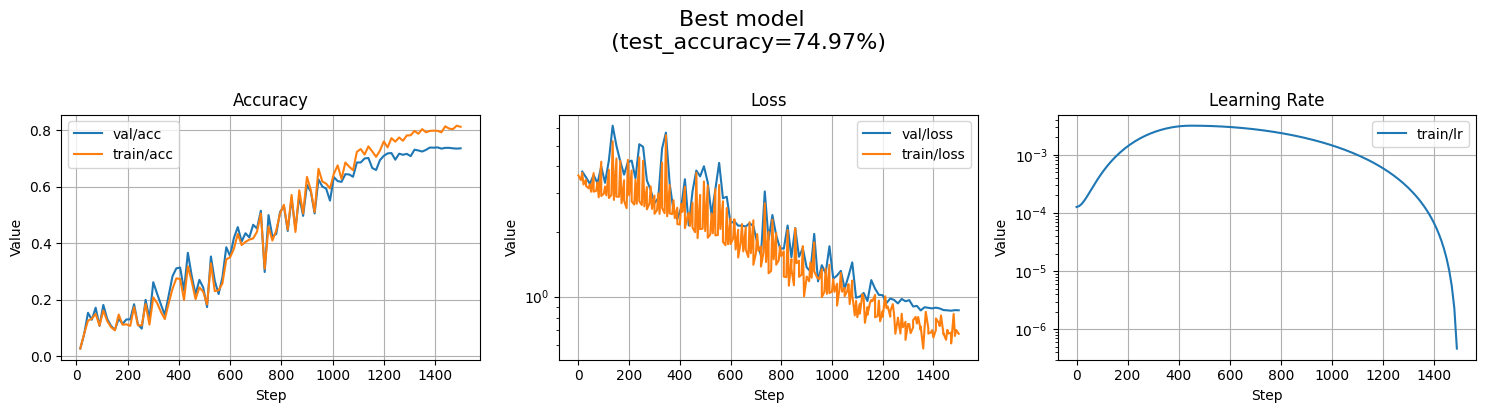

In [11]:
plot_histories(
    grouped_histories=(
        ([h_best, h_best], [h_best, h_best], [h_best]),
    ),
    grouped_metrics=(
        (["val/acc", "train/acc"], ["val/loss", "train/loss"], ["train/lr"]),
    ),
    grouped_titles=(
        ("Accuracy", "Loss", "Learning Rate"),
    ),
    suptitle=f"Best model \n (test_accuracy={acc_best*100:2.2f}%)",
    suptitle_kwargs={"fontsize": 16, "y": 1.02}
)


### 1.5 Ablation study

The ablation focus on both architectural and training parameters. The ablation is not done by training all the possible configurations like in a Grid Search but by modifying one part at a time of the 'optimal' network to investigate whether a different value of that parameter may lead to a better performance.

The ablations are:
- `lr+` tests the upper bound of the learning rate ($10^{-2}$)
- `lr-` tests the lower bound of the learning rate ($10^{-3}$)
- `no_stem` replaces the original stem layer. For a fair comparison, instead of simply removing the stem (which would trivially reduce early receptive field and downsampling) we substitute it with a VGG-style sequence of 3×3 convolutions. This preserves the total depth and parameter budget while isolating the effect of the initial ResNet/Inception-style stem.
- `1+block` tests a higher number of blocks
- `1-block` tests a lower number of blocks
- `1+conv` tests a higher number of convolutions in each block
- `1-conv` tests a lower number of convolutions in each block
- `no_batchnorm` evaluates the effect of removing batch normalization. To ensure a fair comparison, we also implemented `no_batchnorm_lower_lr`, which uses a reduced learning rate. The original version without batch norm can cause training instability and gradient explosions, so this variant isolates whether the observed accuracy drop is due to optimization instability or an inherent performance loss from removing batch normalization.

In [12]:
exec_cfg_base = {
    "batch_size": 256,
    "num_epochs": 100,
    "num_classes": N_CLASSES,
    "lr": 10**(-2.5),
    "wd": 1e-3,
}

base_model_cfg = {
    "n_classes": N_CLASSES,
    "stem": True,
    "input_dim": 3,
    "hidden_dim_first_conv": 64,
    "blocks_structure": [2, 2, 2, 2],
    "mlp_params": None,
    "use_batchnorm": True,
    "dropout_p": 0.0,
}

experiments = {
    "lr+": {
        "exec_cfg": {"lr": 1e-2},
    },
    "lr-": {
        "exec_cfg": {"lr": 1e-3},
    },
    "no_stem": {
        "model_cfg": {"stem": False, "blocks_structure": [1,1,2,2,2,2]},
    },
    "1+block": {
        "model_cfg": {"blocks_structure": [2,2,2,2,2]},
    },
    "1-block": {
        "model_cfg": {"blocks_structure": [2,2,2]},
    },
    "1+conv": {
        "model_cfg": {"blocks_structure": [3,3,3,3]},
    },
    "1-conv": {
        "model_cfg": {"blocks_structure": [1,1,1,1]},
    },
    "no_batchnorm": {
        "model_cfg": {"use_batchnorm": False},
    },
    "no_batchnorm_lower_lr": {
        "model_cfg": {"use_batchnorm": False},
        "exec_cfg": {"lr": 1e-4}
    }
}

results = {}
for experiment_name, exp_cfg in experiments.items():
    # Clone the best_model dicts to allow more readable specific variation
    model_cfg = base_model_cfg.copy()
    exec_cfg = exec_cfg_base.copy()

    # Apply override
    if "model_cfg" in exp_cfg:
        model_cfg.update(exp_cfg["model_cfg"])
    if "exec_cfg" in exp_cfg:
        exec_cfg.update(exp_cfg["exec_cfg"])

    exec_cfg["run_name"] = experiment_name

    acc, history = train_and_test(
        model=MyClassifier(**model_cfg),
        cfg=exec_cfg,
        train_dataset=train_dataset,
        val_dataset=val_dataset,
        test_dataset=test_dataset,
        use_wandb=True,
        verbose=False,
        cache_dir=CACHE_DIR
    )

    results[experiment_name] = {'accuracy': acc, 'history': history}

As we can see, all the ablations performs worse than the best model but we can make some observations:
1. The **learning rate** doesn't change that much, smaller values produce the same output and higher values slightly underperform.
2. The Inception/ResNet **stem layer** has an important impact, providing an increment of around 9% in accuracy.
3. Similarly to the learning rate, also the **number of blocks** don't change that much, providing an accuracy increment of the 2/3% more or less.
4. The same also for the **number of convolutions**, that provide an increment of 3/4%
5. The **batchnorm** is crucial. As introduced before, simply removing batchnorm leads to gradient explosion (the loss peaks at $10^9$ and converges at $10^3$) and the accuracy drops by around 70%. To balance this effect we wanted to make the gradient more cautious and so we decreased the learning rate by an order of magnitude but the results kept being importantly low.

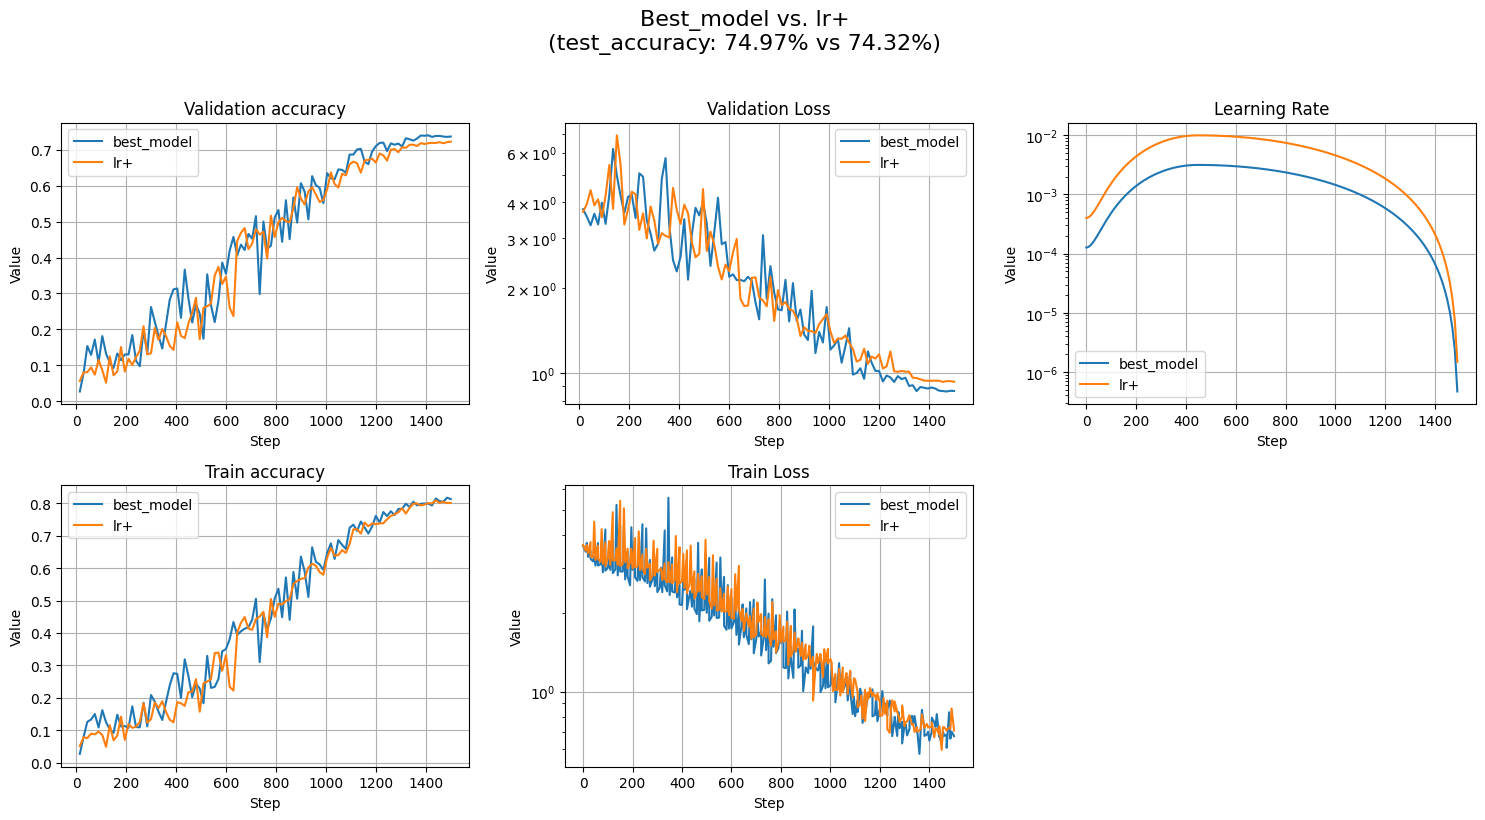

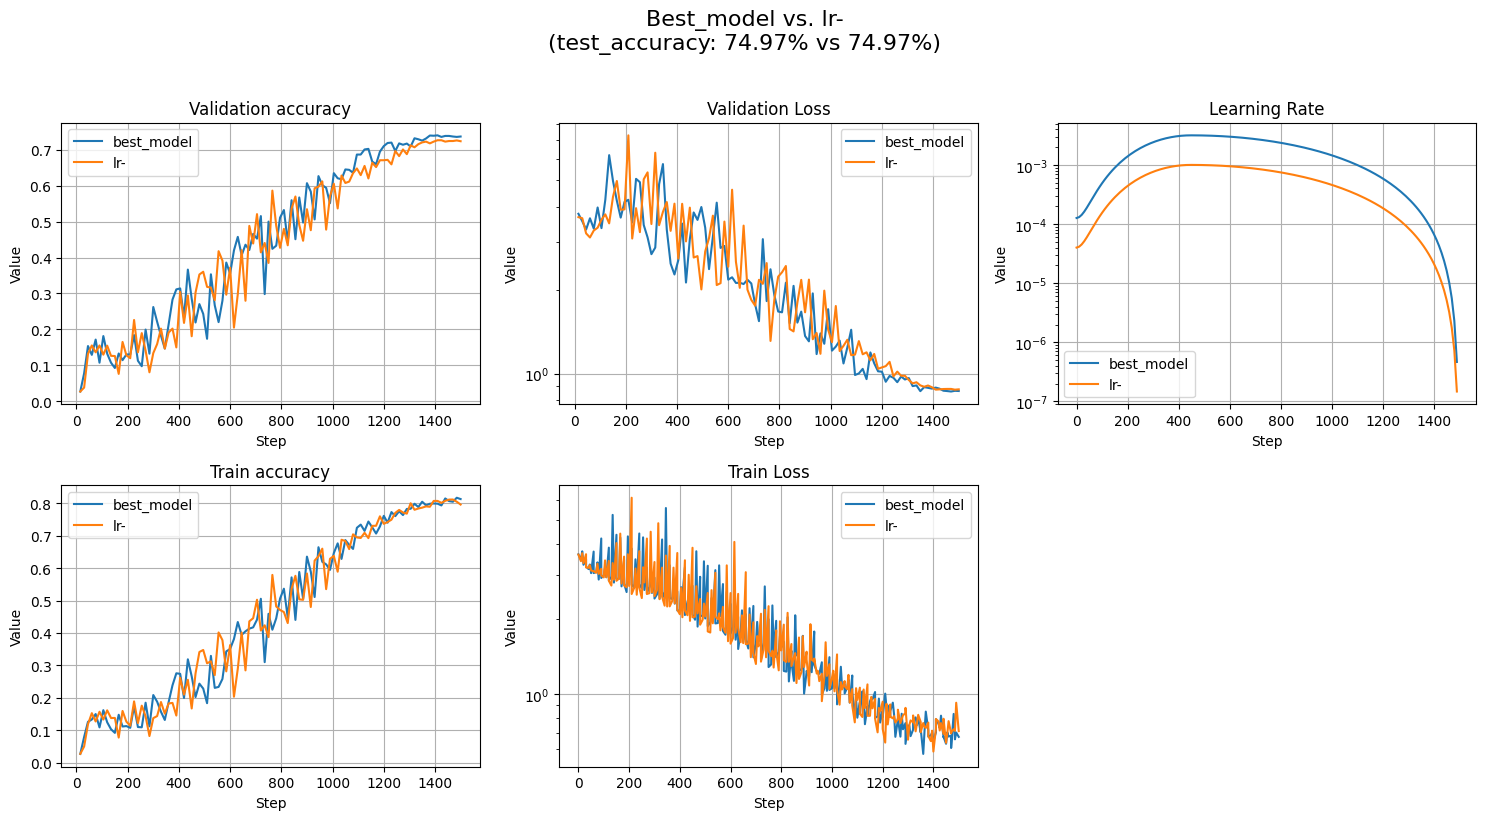

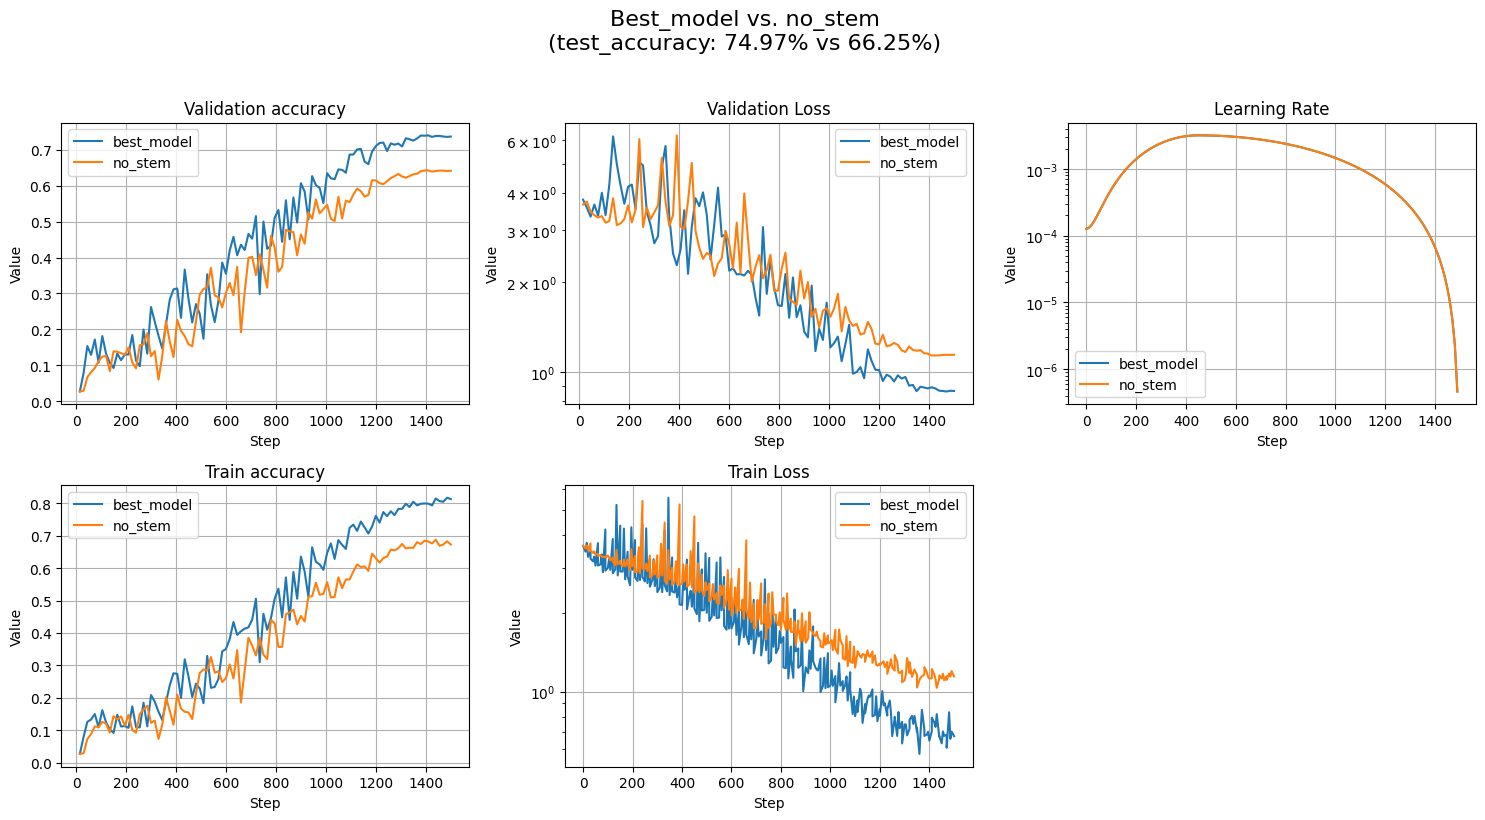

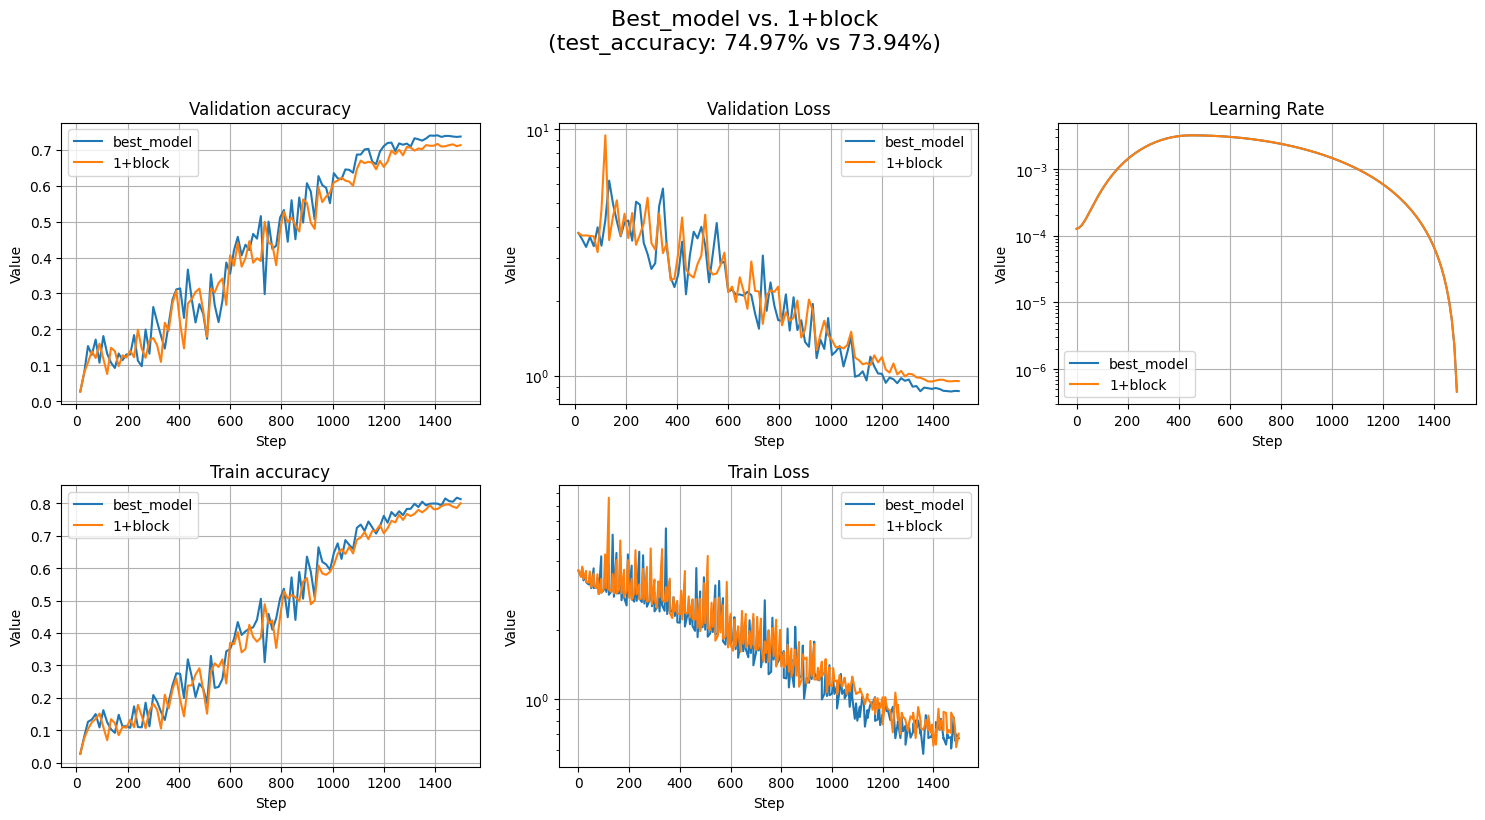

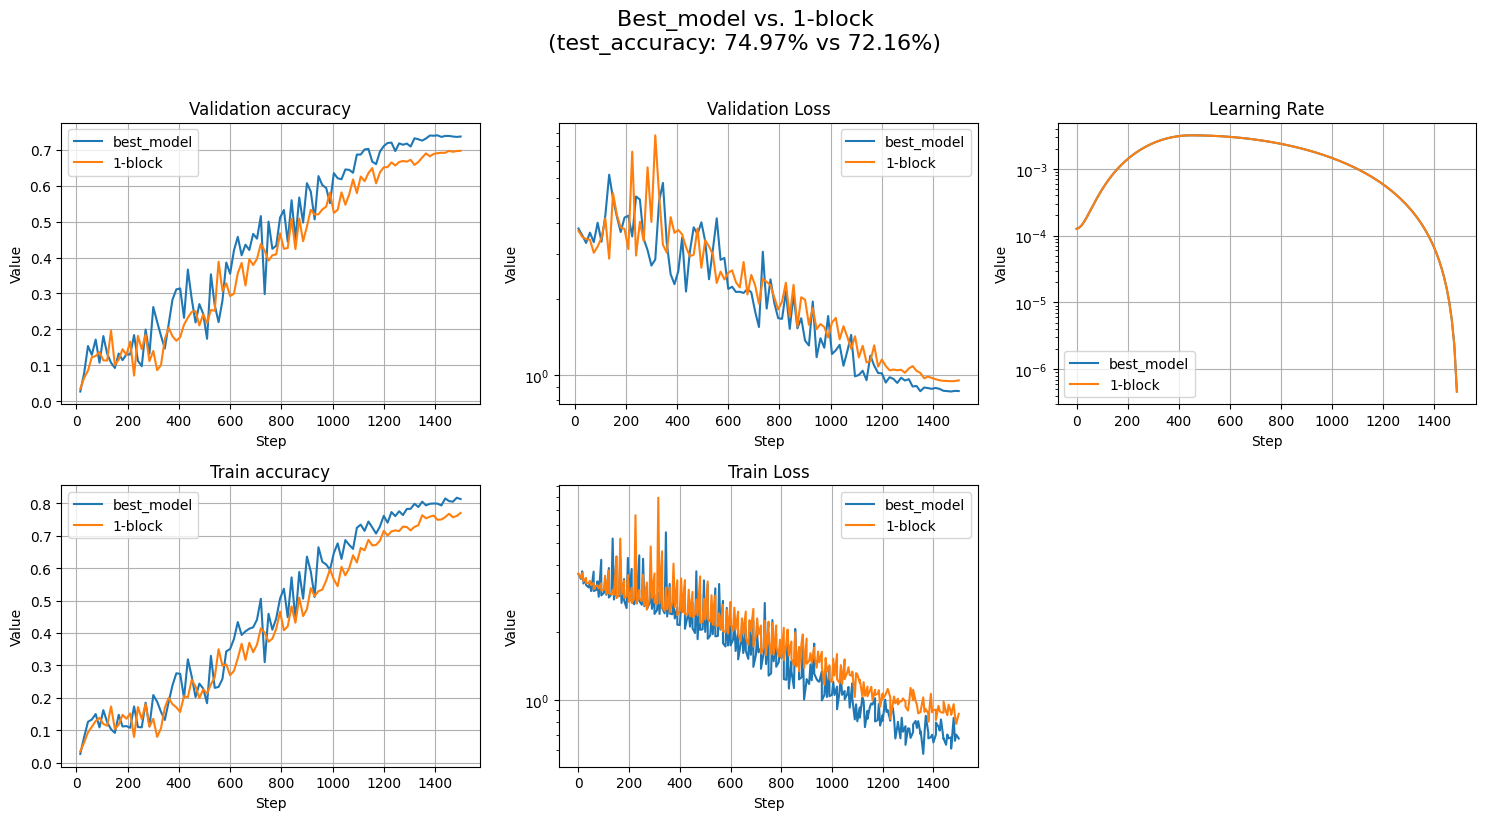

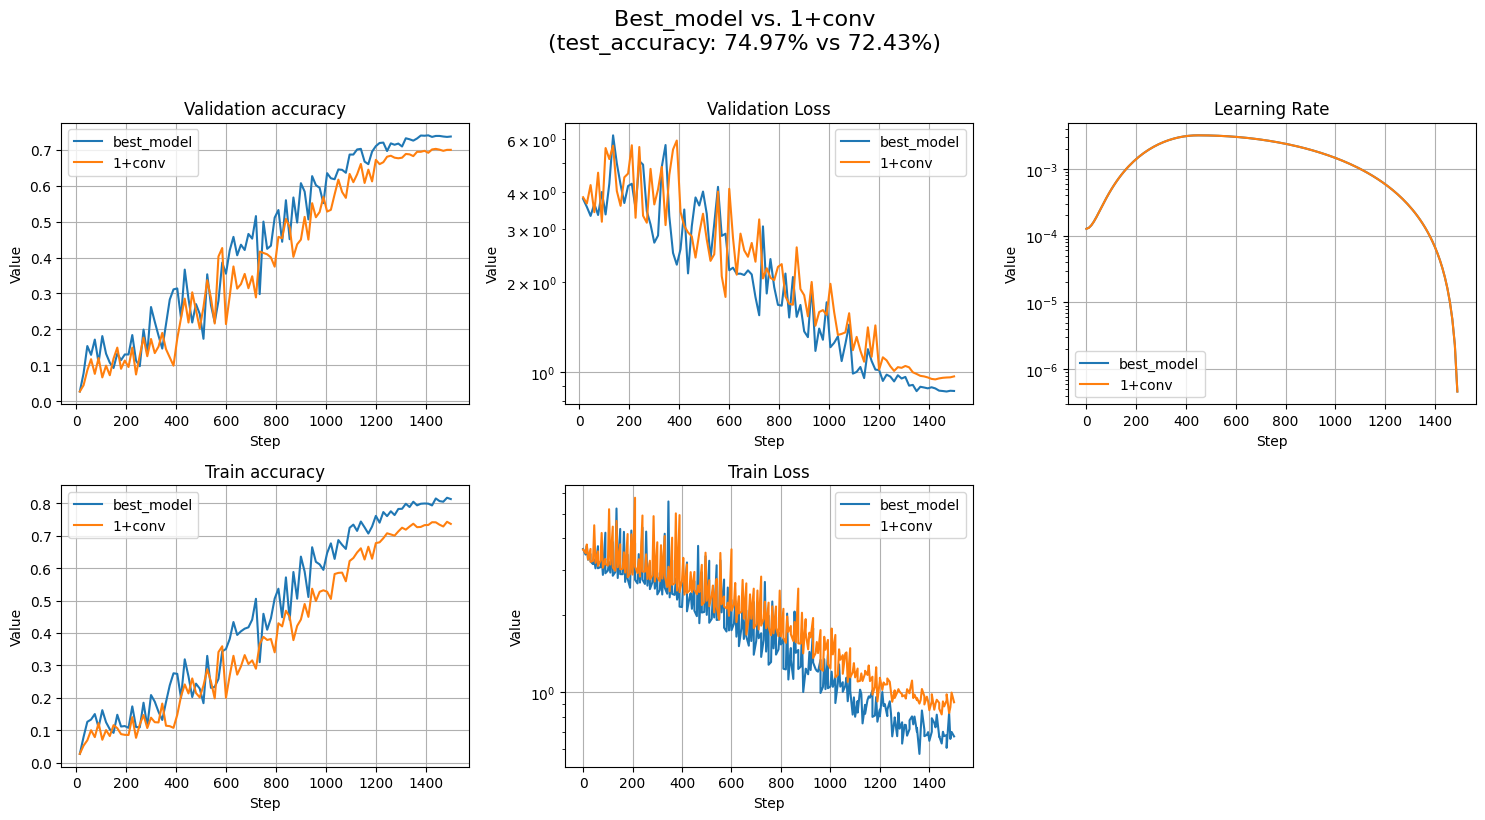

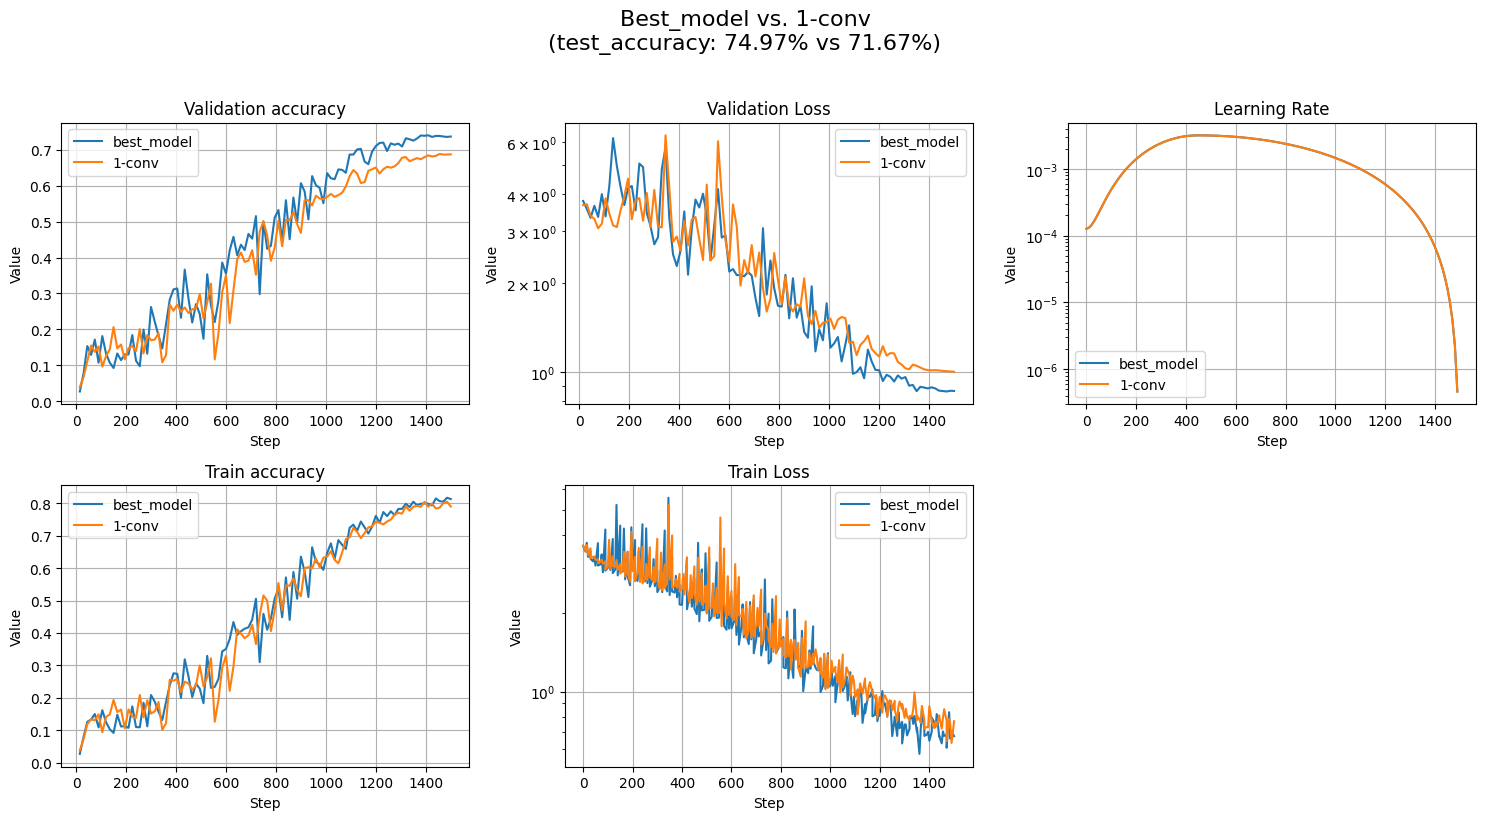

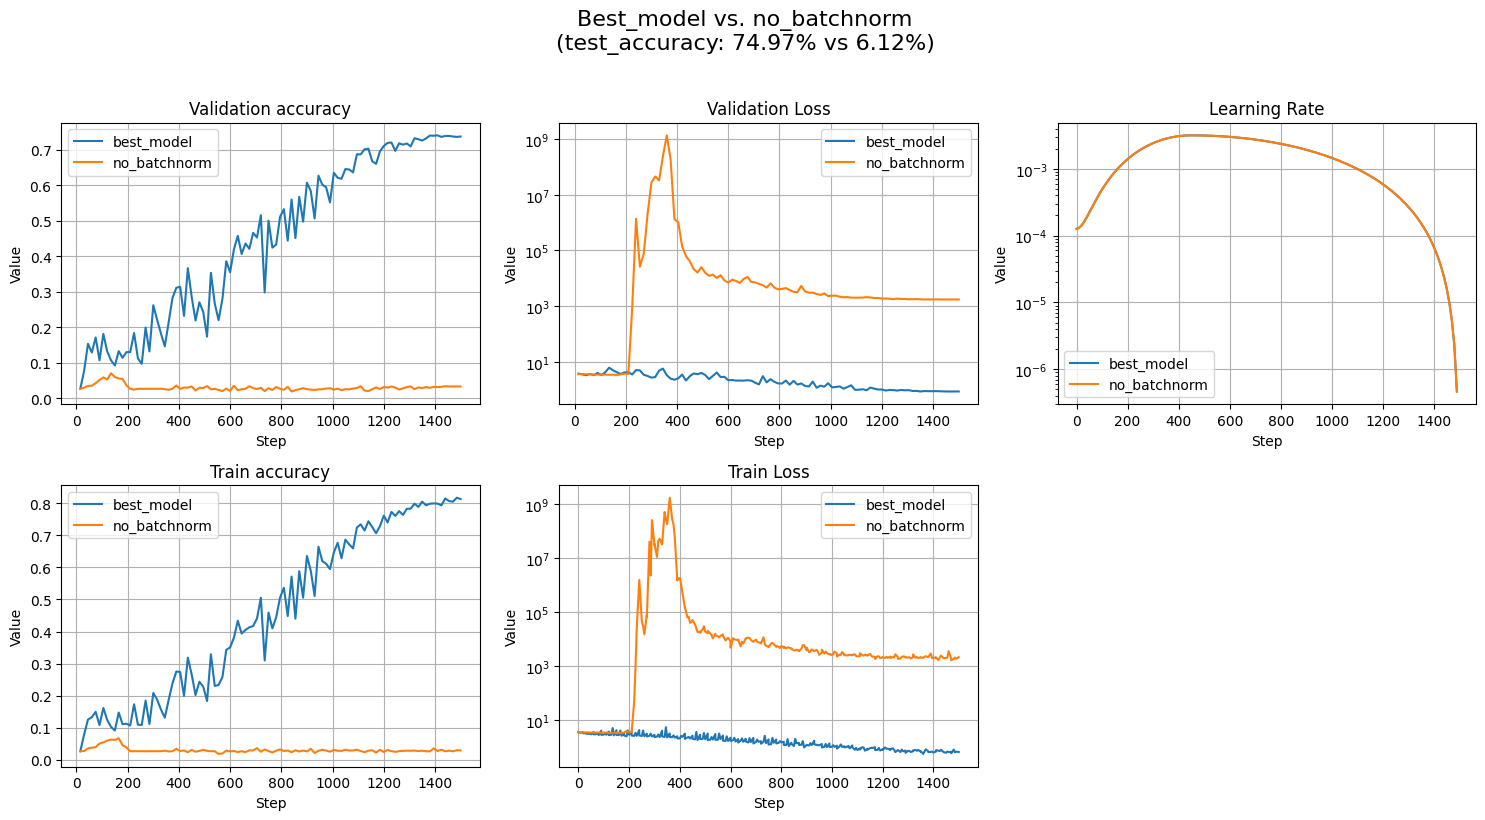

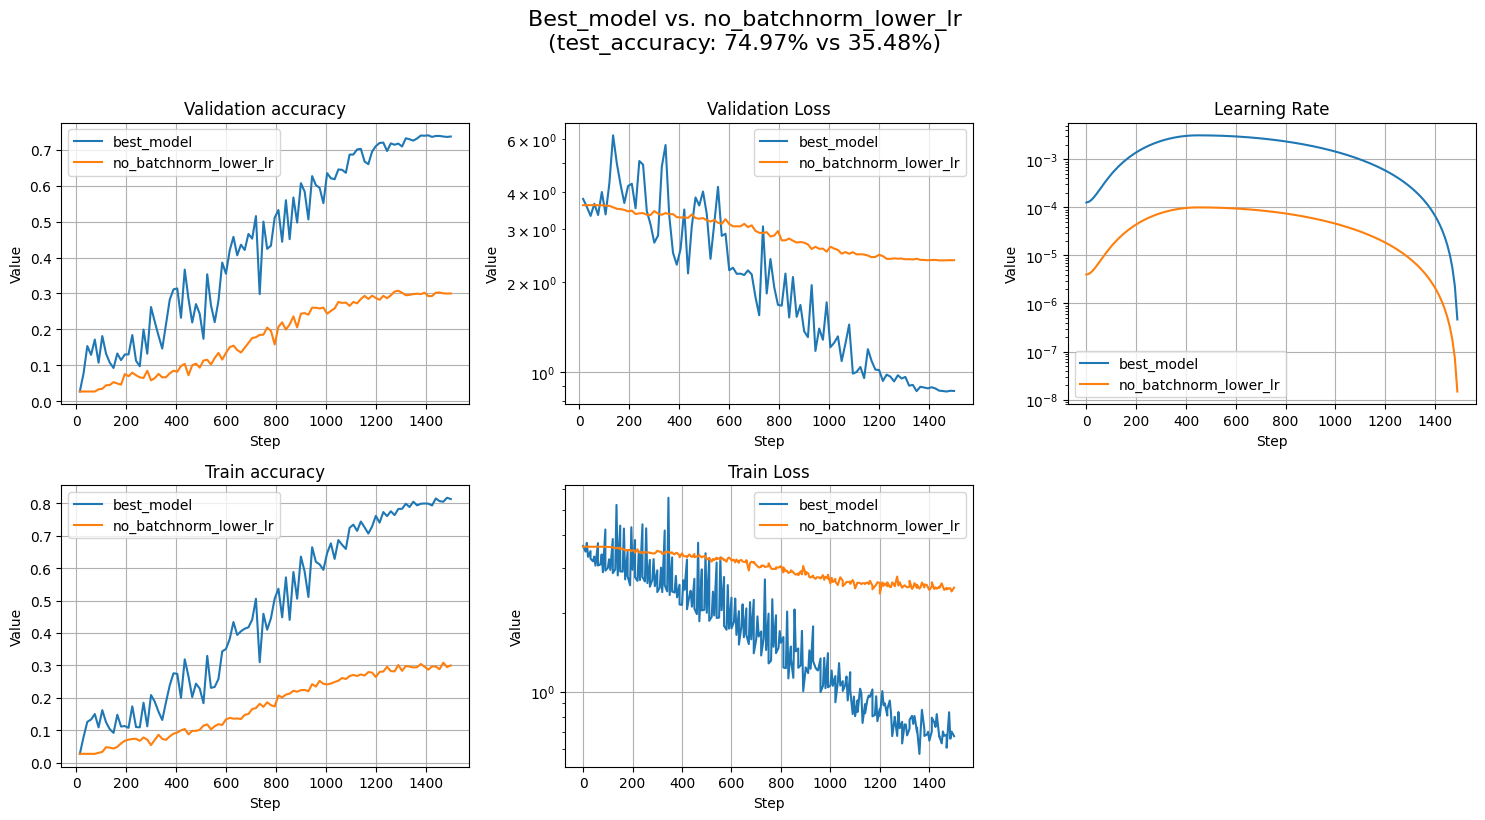

In [13]:
for experiment_name, result in results.items():
  plot_histories(
    grouped_histories=(
        ([h_best, result["history"]], [h_best, result["history"]], [h_best,result["history"]]),
        ([h_best, result["history"]], [h_best, result["history"]]) ,
    ),
    grouped_metrics=(
        (["val/acc", "val/acc"], ["val/loss", "val/loss"], ["train/lr", "train/lr"]),
        (["train/acc", "train/acc"], ["train/loss", "train/loss"]),
    ),
    grouped_titles=(
        ("Validation accuracy", "Validation Loss", "Learning Rate"),
        ("Train accuracy", "Train Loss"),
    ),
    grouped_names=(
        (["best_model",experiment_name], ["best_model",experiment_name], ["best_model",experiment_name]),
        (["best_model",experiment_name], ["best_model",experiment_name]),
    ),
    suptitle="Best_model vs. " + experiment_name + f"\n(test_accuracy: {acc_best*100:.2f}% vs {result['accuracy']*100:.2f}%)",
    suptitle_kwargs={"fontsize": 16, "y": 1.02}
  )

As we mentioned before the use of a lower learning rate without batchnorm made a great difference (30% in accuracy).

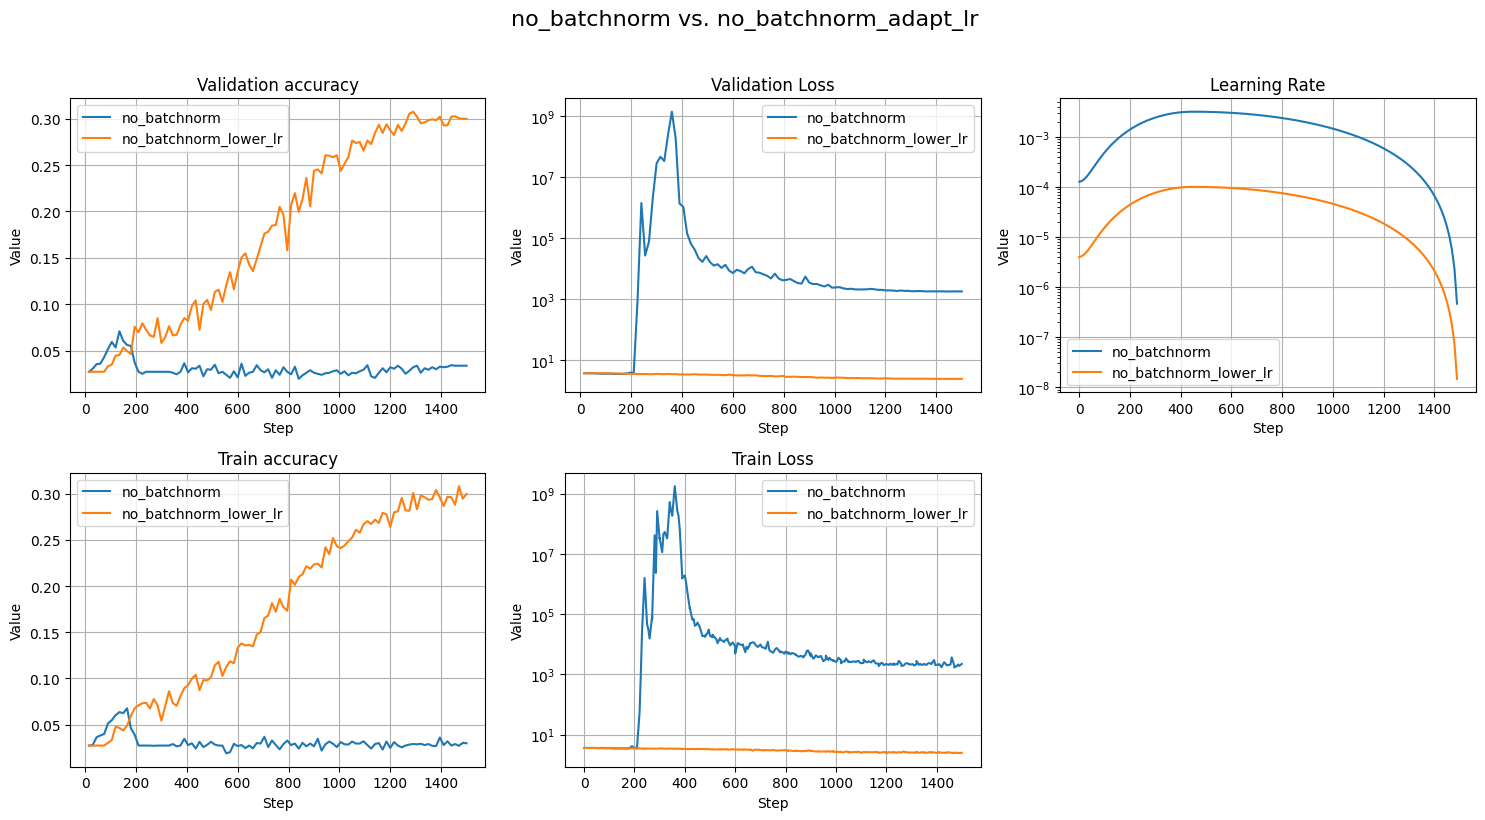

In [14]:
h1 = results["no_batchnorm"]["history"]
h2 = results["no_batchnorm_lower_lr"]["history"]

plot_histories(
    grouped_histories=(
        ([h1, h2], [h1, h2], [h1,h2]),
        ([h1, h2], [h1, h2]) ,
    ),
    grouped_metrics=(
        (["val/acc", "val/acc"], ["val/loss", "val/loss"], ["train/lr", "train/lr"]),
        (["train/acc", "train/acc"], ["train/loss", "train/loss"]),
    ),
    grouped_titles=(
        ("Validation accuracy", "Validation Loss", "Learning Rate"),
        ("Train accuracy", "Train Loss"),
    ),
    grouped_names=(
        (["no_batchnorm","no_batchnorm_lower_lr"], ["no_batchnorm","no_batchnorm_lower_lr"], ["no_batchnorm","no_batchnorm_lower_lr"]),
        (["no_batchnorm","no_batchnorm_lower_lr"], ["no_batchnorm","no_batchnorm_lower_lr"]),
    ),
    suptitle="no_batchnorm vs. no_batchnorm_adapt_lr",
    suptitle_kwargs={"fontsize": 16, "y": 1.02}
)

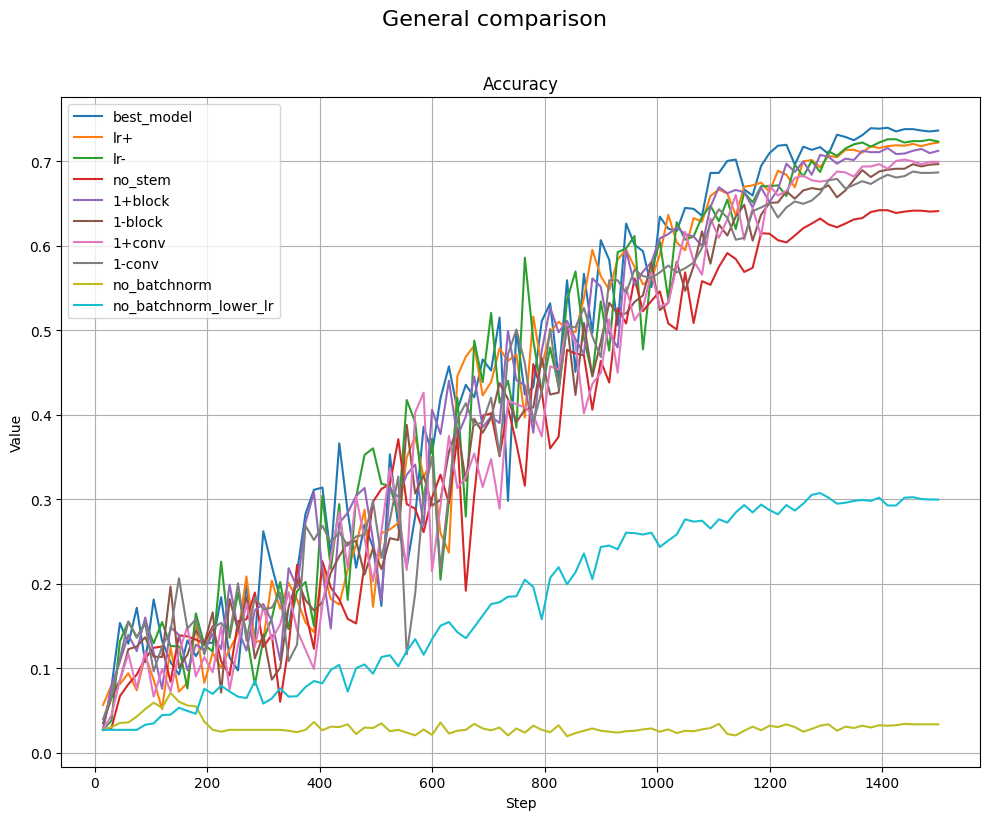

In [15]:
grouped_histories = (([h_best],),)
grouped_metrics = ((["val/acc"],),)
grouped_names = ((["best_model"],),)
grouped_titles=(("Accuracy",),)

for experiment_name, result in results.items():
  grouped_histories[0][0].append(result["history"])
  grouped_metrics[0][0].append("val/acc")
  grouped_names[0][0].append(experiment_name)

plot_histories(grouped_histories, grouped_metrics,
  grouped_titles=grouped_titles,
  grouped_names=grouped_names,
  suptitle="General comparison",
  suptitle_kwargs={"fontsize": 16, "y": 1.02},
  figsize=(10,8)
)

## Part 2: fine-tune an existing network

Your goal is to fine-tune a pretrained ResNet-18 model on `OxfordPetDataset`. Use the implementation provided by PyTorch, i.e. the opposite of part 1. Specifically, use the PyTorch ResNet-18 model pretrained on ImageNet-1K (V1). Divide your fine-tuning into two parts:

2A. First, fine-tune the ResNet-18 with the same training hyperparameters you used for your best model in part 1.

2B. Then, tweak the training hyperparameters in order to increase the accuracy on the test split. Justify your choices by analyzing the training plots and/or citing sources that guided you in your decisions — papers, blog posts, YouTube videos, or whatever else you may find useful. You should consider yourselves satisfied once you obtain a classification accuracy on the test split of ~90%.

### 2A)

We fine-tuned the ResNet-18 by freezing all the layers except for the `fc` layer that is replaced to cover the number of our classes and fit with the training hyperparameters used for `best_model`. Surprisely, the result is already very close to 90% on the test split and converges very quickly .

This is definetly better than the results obtained with the previous model and highlights how much transfer learning may play an important role in image classification.

In [16]:
modelA = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Fine-tuning: freeze all layers except the final classifier layer
for param in modelA.parameters():
    param.requires_grad = False
modelA.fc = nn.Linear(modelA.fc.in_features, N_CLASSES)

acc_rn1, h_rn1 = train_and_test(
    model = modelA,
    cfg = {
        "batch_size" : 256,
        "run_name" : "ResNet18_original_training_params",
        "num_epochs" : 100,
        "num_classes" : N_CLASSES,
        "lr" : 10**(-2.5),
        "wd" : 1e-3,
    },
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    test_dataset=test_dataset,
    use_wandb=False,
    verbose=False,
    cache_dir=CACHE_DIR,
)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 91.0MB/s]


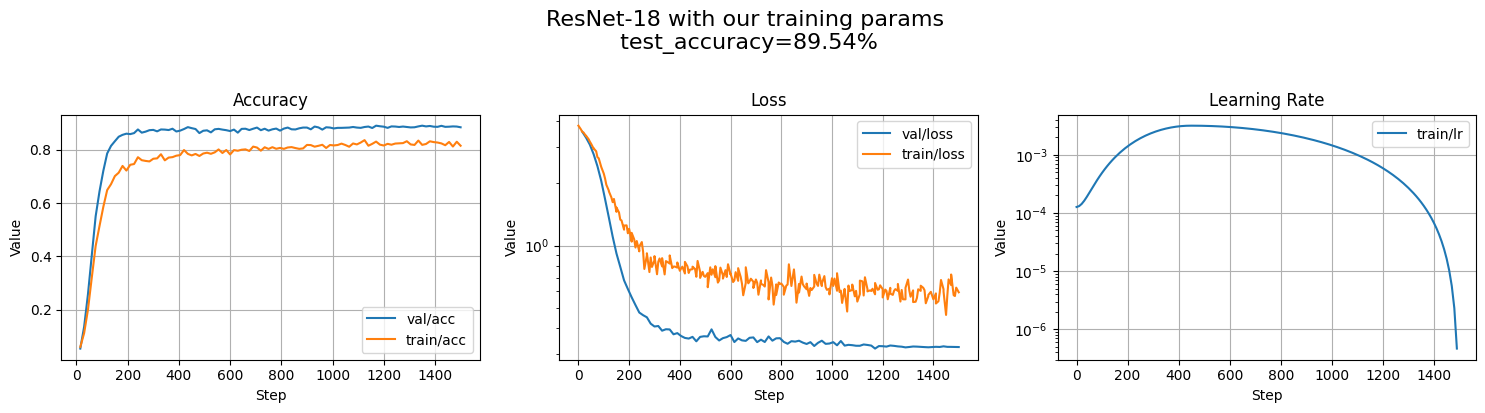

In [17]:
plot_histories(
    grouped_histories=(
        ([h_rn1, h_rn1], [h_rn1, h_rn1], [h_rn1]),
    ),
    grouped_metrics=(
        (["val/acc", "train/acc"], ["val/loss", "train/loss"], ["train/lr"]),
    ),
    grouped_titles=(
        ("Accuracy", "Loss", "Learning Rate"),
    ),
    suptitle="ResNet-18 with our training params" + f"\n test_accuracy={acc_rn1*100:.2f}%",
    suptitle_kwargs={"fontsize": 16, "y": 1.02}
)


### 2B)

Looking at the different representations we got for the different models in WANDB there was a specific issue: when fitting a model, the training reached very fast a plateau on both loss and accuracy from which it was difficult to improve from. This is normal usually, however, as the model did not pass the benchmark of 90% accuracy on test set, this could be problematic for this specific task.
The main hyperparameters that could be responsible for this could be learning rate and batch size as it is mentioned in this article (https://medium.com/kirey-group/how-to-achieve-super-convergence-and-exploit-one-cycle-policy-a-simple-guide-430c1e0a3c1e). <br>
For this reason the idea was after a first training by unfreezing the layer 3 and layer 4 of the ResNet, with 10 epochs and just reducing the the learning rate to $10^{-4.5}$ for the layers of the ResNet and $10^{-4.5}\cdot 0.5$ for the linear layer. The weight decay is set lower on the layers of the ResNet as they are pretrained, while an higher was chosen for preventing overfitting.

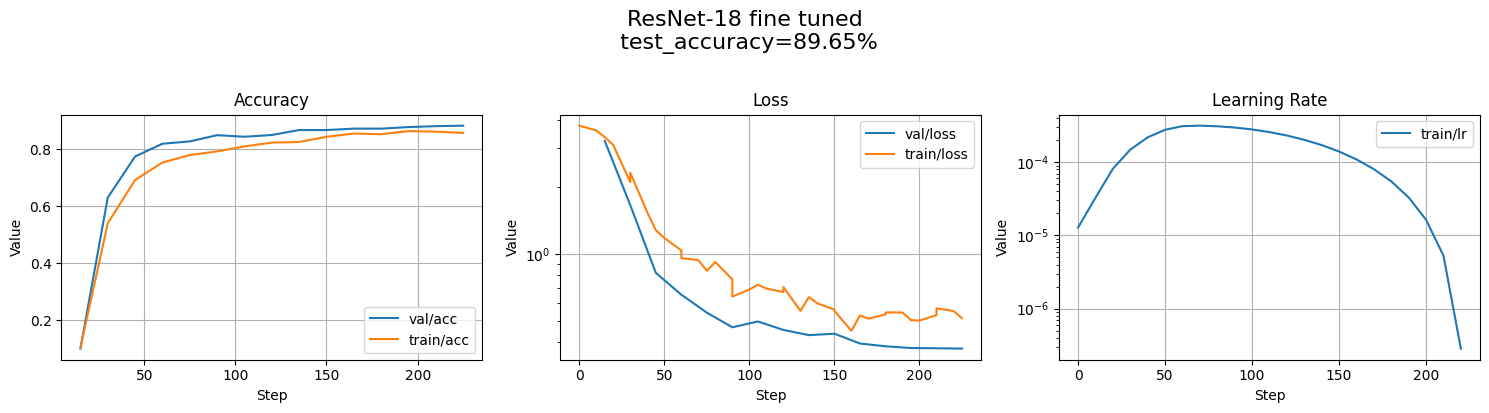

In [18]:
modelB = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
modelB.fc = nn.Linear(modelB.fc.in_features, N_CLASSES)

stem_names = ['conv1', 'bn1']
block_names = ['layer1', 'layer2']
block_names2=['layer3', 'layer4']
head_names = ['fc']

stem_params, block_params, block_params2, head_params = [], [], [], []
for name, param in modelB.named_parameters():
        if not param.requires_grad:
            continue  # Skip frozen layers
        if any(name.startswith(n) for n in stem_names):
            param.requires_grad = False
        elif any(name.startswith(n) for n in block_names):
            param.requires_grad = False
        elif any(name.startswith(n) for n in block_names2):
            block_params2.append(param)
        elif any(name.startswith(n) for n in head_names):
            head_params.append(param)

cfg = {
    "batch_size" : 256,
    "num_epochs" : 10,
    "run_name" : "ResNet18_finetuned",
    "num_classes" : N_CLASSES,
    "lr" : 10**(-(3.5)),
    "wd" : 1e-4,
}

acc_rn2_1, h_rn2_1 = train_and_test(
    model = modelB,
    cfg = cfg,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    test_dataset=test_dataset,
    use_wandb=False,
    verbose=False,
    cache_dir=CACHE_DIR,
    fine_tune=[
        {'params': block_params2, 'lr': cfg["lr"]* 0.1, 'wd': cfg['wd']*0.4},    # Base LR for blocks
        {'params': head_params, 'lr': cfg["lr"] * 0.5, 'wd': cfg['wd']*0.8},     # Faster LR for head
    ]
)

plot_histories(
    grouped_histories=(
        ([h_rn2_1, h_rn2_1], [h_rn2_1, h_rn2_1], [h_rn2_1]),
    ),
    grouped_metrics=(
        (["val/acc", "train/acc"], ["val/loss", "train/loss"], ["train/lr"]),
    ),
    grouped_titles=(
        ("Accuracy", "Loss", "Learning Rate"),
    ),
    suptitle="ResNet-18 fine tuned" + f"\n test_accuracy={acc_rn2_1*100:.2f}%",
    suptitle_kwargs={"fontsize": 16, "y": 1.02}
)

As it is possible to see, this did not improve much from the results obtained in 2A. We wanted to pass 90% so we started from this model and we reduced just the learning rate.

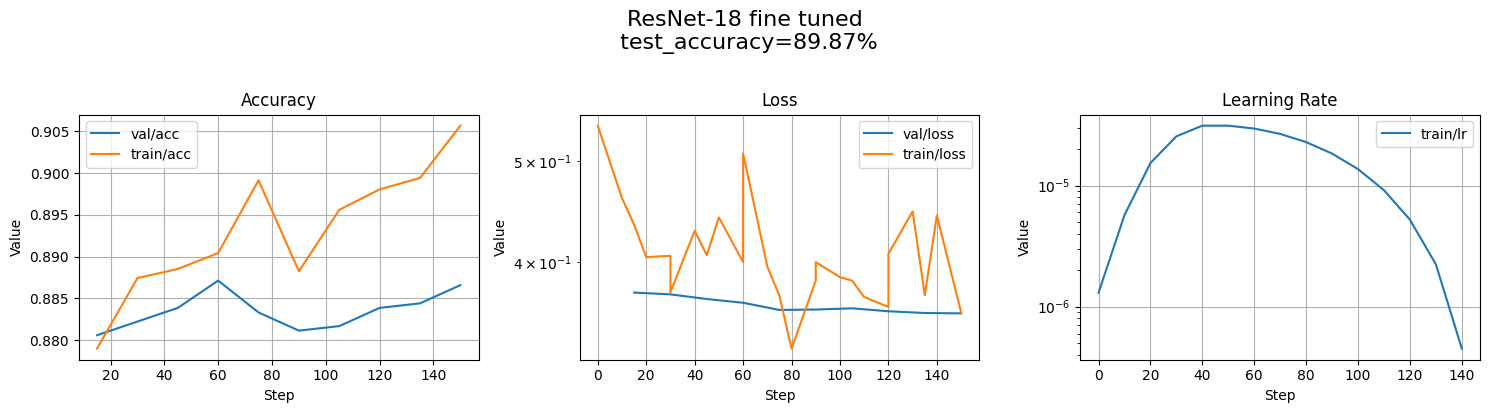

In [19]:
cfg = {
    "batch_size" : 256,
    "num_epochs" : 10,
    "run_name" : "ResNet18_finetuned2",
    "num_classes" : N_CLASSES,
    "lr" : 10**(-(4.5)),
    "wd" : 1e-4,
}


acc_rn2_2, h_rn2_2 = train_and_test(
    model = modelB,
    cfg = cfg,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    test_dataset=test_dataset,
    use_wandb=False,
    verbose=False,
    cache_dir=CACHE_DIR,
    fine_tune=[
        {'params': block_params2, 'lr': cfg["lr"]* 0.1, 'wd': cfg['wd']*0.4},    # Base LR for blocks
        {'params': head_params, 'lr': cfg["lr"] * 0.5, 'wd': cfg['wd']*0.8},     # Faster LR for head
    ]
)

plot_histories(
    grouped_histories=(
        ([h_rn2_2, h_rn2_2], [h_rn2_2, h_rn2_2], [h_rn2_2]),
    ),
    grouped_metrics=(
        (["val/acc", "train/acc"], ["val/loss", "train/loss"], ["train/lr"]),
    ),
    grouped_titles=(
        ("Accuracy", "Loss", "Learning Rate"),
    ),
    suptitle="ResNet-18 fine tuned" + f"\n test_accuracy={acc_rn2_2*100:.2f}%",
    suptitle_kwargs={"fontsize": 16, "y": 1.02}
)

This seems it is improving but not enough, so we could try chaning the batch size, to increase the number of steps and therefore have a more gradual evolution of the learning rate. So the same maximum learning rate was kept the same, but with a batch size of 64.

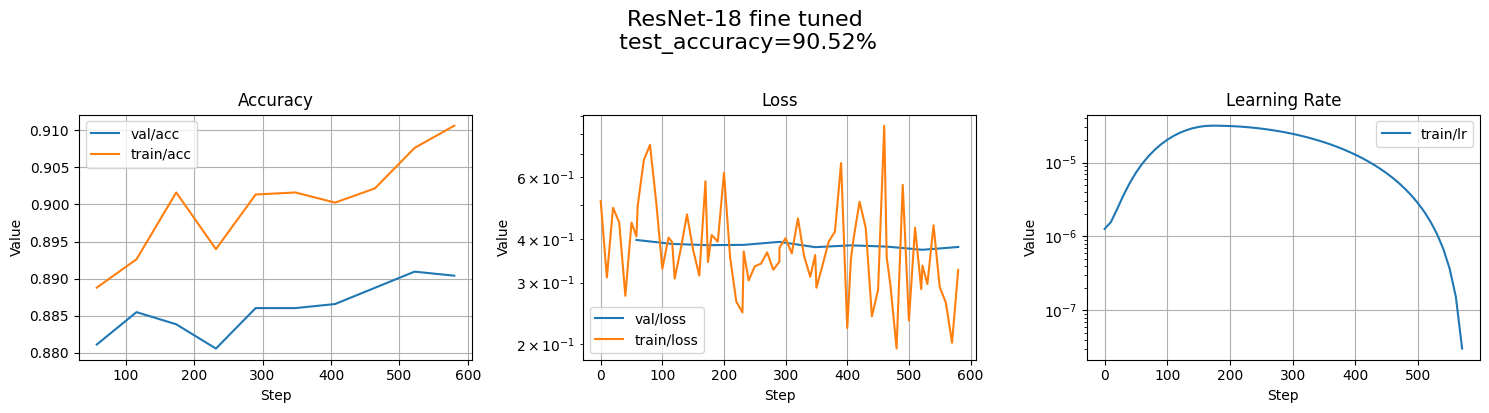

In [20]:
cfg = {
    "batch_size" : 64,
    "num_epochs" : 10,
    "run_name" : "ResNet18_finetuned3",
    "num_classes" : N_CLASSES,
    "lr" : 10**(-(4.5)),
    "wd" : 1e-4,
}


acc_rn2_3, h_rn2_3 = train_and_test(
    model = modelB,
    cfg = cfg,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    test_dataset=test_dataset,
    use_wandb=False,
    verbose=False,
    cache_dir=CACHE_DIR,
    fine_tune=[
        {'params': block_params2, 'lr': cfg["lr"]* 0.1, 'wd': cfg['wd']*0.4},    # Base LR for blocks
        {'params': head_params, 'lr': cfg["lr"] * 0.5, 'wd': cfg['wd']*0.8},     # Faster LR for head
    ]
)

plot_histories(
    grouped_histories=(
        ([h_rn2_3, h_rn2_3], [h_rn2_3, h_rn2_3], [h_rn2_3]),
    ),
    grouped_metrics=(
        (["val/acc", "train/acc"], ["val/loss", "train/loss"], ["train/lr"]),
    ),
    grouped_titles=(
        ("Accuracy", "Loss", "Learning Rate"),
    ),
    suptitle="ResNet-18 fine tuned" + f"\n test_accuracy={acc_rn2_3*100:.2f}%",
    suptitle_kwargs={"fontsize": 16, "y": 1.02}
)

This now passed the benchmark, trying other regularization methods which were mentioned showed to reduce the accuracy and the performance of the model. This was an interesting part that was highlighted by the paper "Super-Convergence: Very Fast Training of Neural Networks Using Large Learning Rates" by Leslie N. Smith, Nicholay Topin.<br>

To understand why improving performance beyond this benchmark is difficult, we examine the test errors using confusion matrices for the final models in 2A and 2B.

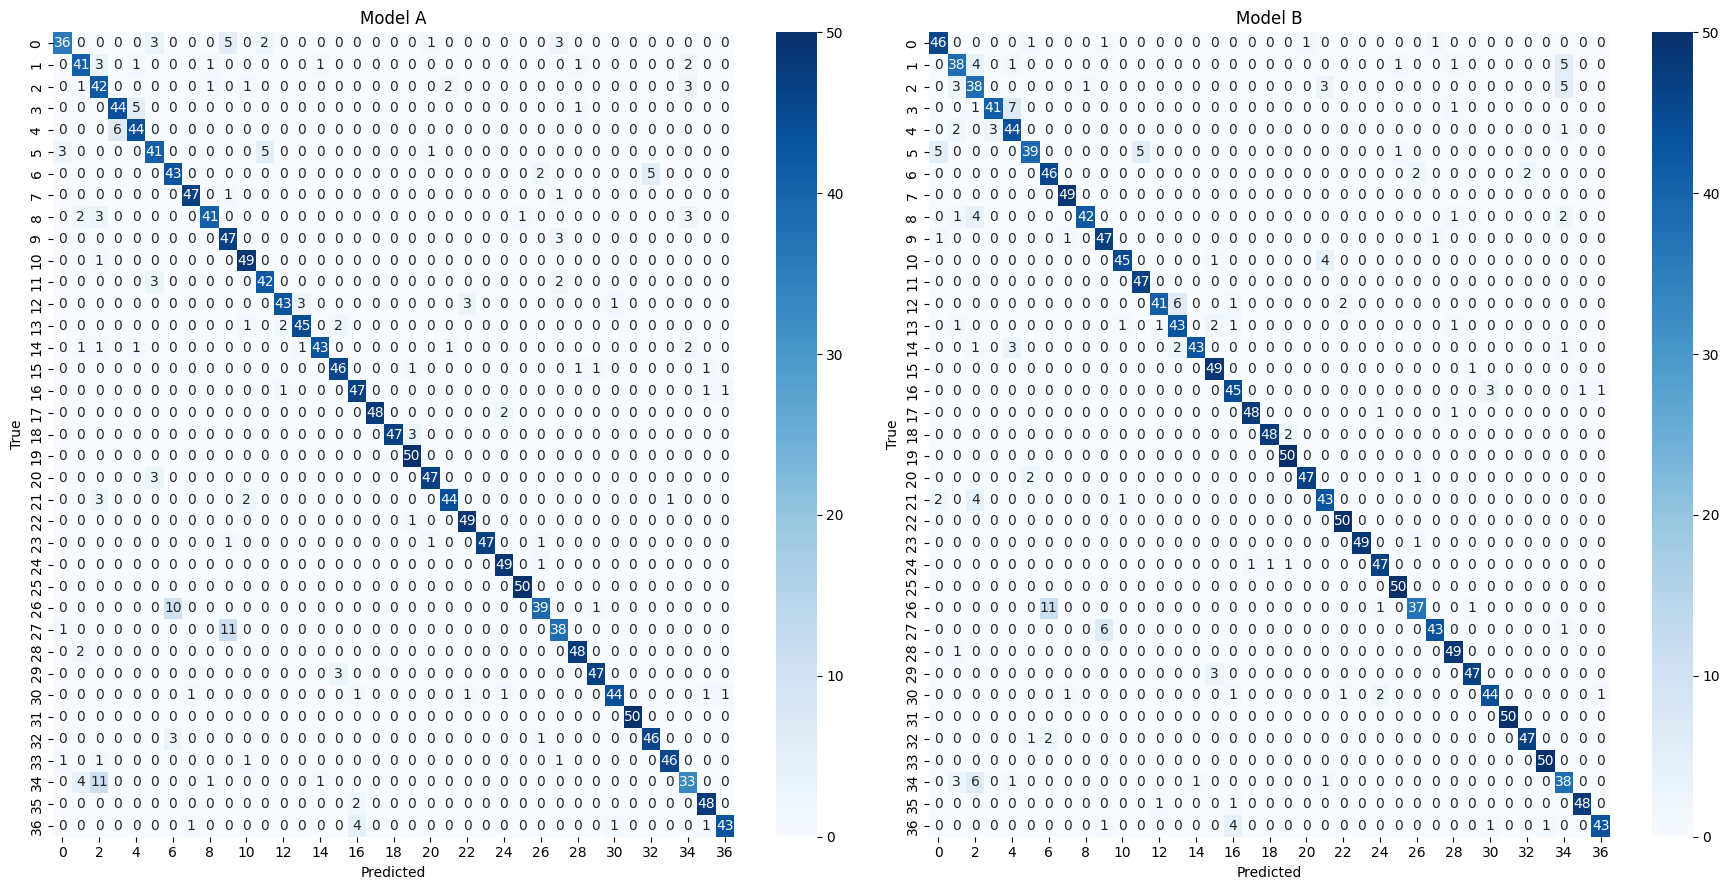

In [21]:
confmat = ConfusionMatrix(task="multiclass", num_classes=N_CLASSES).to(DEVICE)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False, num_workers=2)

models = [modelA, modelB]
names = ["Model A", "Model B"]

fig, axes = plt.subplots(1, len(models), figsize=(18, 9))

for i, (model, name) in enumerate(zip(models, names)):
    confmat.reset()
    model.eval()
    model.to(DEVICE)

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            preds = model(imgs).argmax(dim=-1)
            confmat.update(preds, labels)

    cm = confmat.compute().cpu().numpy()

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(name)
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("True")

plt.tight_layout()
plt.show()


In 2A, a few classes exhibit noticeably higher misclassification rates, indicating potential targets for focused improvement. In 2B, errors are more evenly distributed across classes, suggesting that the modifications leading to performance gains also introduced new errors in classes that were previously well recognized.

This redistribution of errors reduces the possibility of selectively improving specific classes without harming others, making further accuracy gains increasingly constrained.